In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_parquet("../data/cleaned/train_data.parquet")

Plotting Class Imbalance...


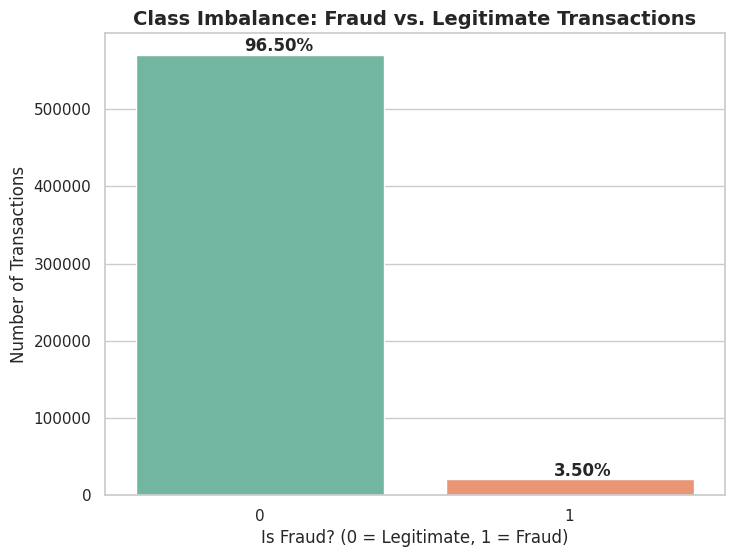

In [4]:
print("Plotting Class Imbalance...")

# Set a clean, professional theme for the paper
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create the count plot
ax = sns.countplot(x='isFraud', hue="isFraud", data=df, palette='Set2', legend=False)

# Add titles and labels
plt.title('Class Imbalance: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Calculate and annotate the percentages on top of the bars
total = len(df)
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Find the center of the bar for x-coordinate
    x = p.get_x() + p.get_width() / 2 - 0.05
    # Find the top of the bar for y-ccoordinate, add a little padding
    y = p.get_height() + 5000 
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

Plotting Correlation Heatmap...


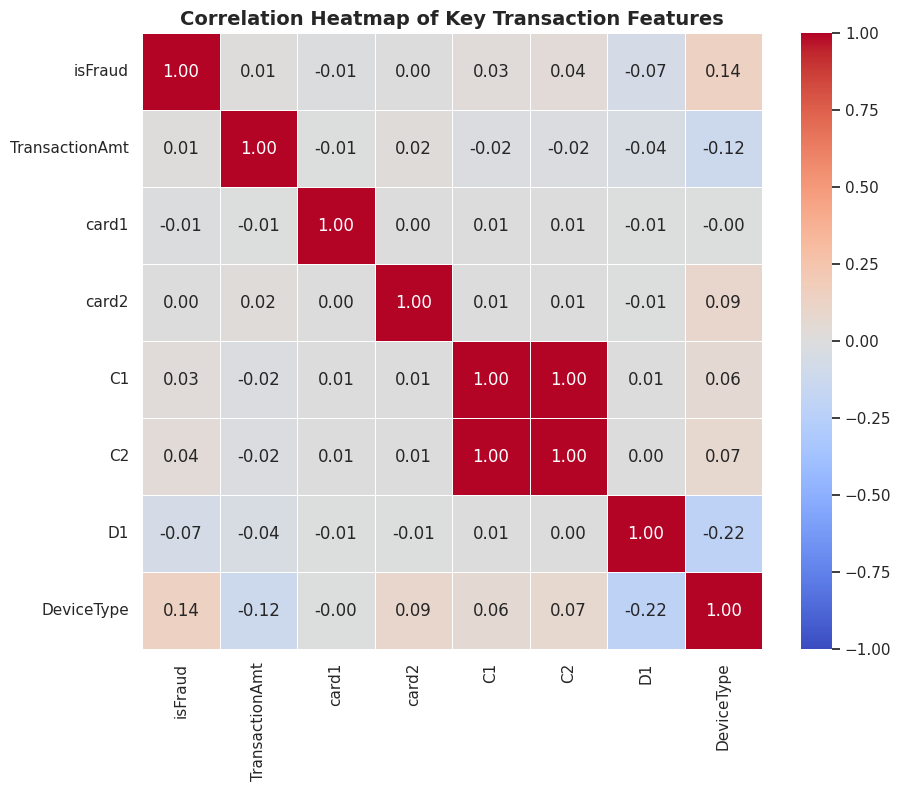

In [5]:
print("Plotting Correlation Heatmap...")

# 1. Select a targeted subset of features to keep the plot readable
subset_cols = [
    'isFraud', 'TransactionAmt', 'card1', 'card2', 
    'C1', 'C2', 'D1', 'DeviceType'
]

plt.figure(figsize=(10, 8))

# 2. Calculate the correlation matrix only for these columns
corr_matrix = df[subset_cols].corr()

# 3. Plot the heatmap
# annot=True puts the actual numbers in the boxes
# cmap='coolwarm' makes strong negative correlations blue and strong positive ones red
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Key Transaction Features', fontsize=14, fontweight='bold')
plt.show()

Plotting the transaction amount vs hour of the day hexbin plot


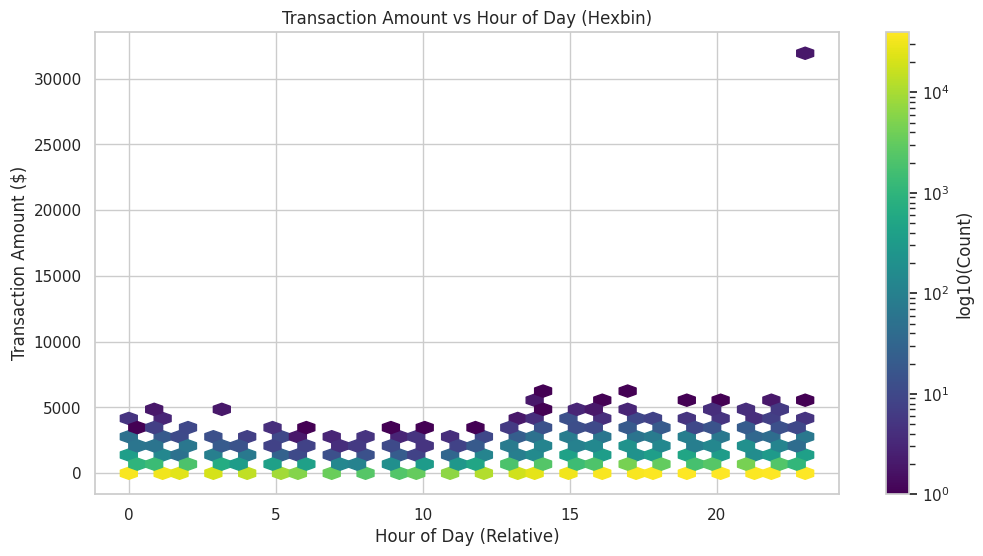

In [6]:
df["hour"] = (df["TransactionDT"] // 3600) % 24
print("Plotting the transaction amount vs hour of the day hexbin plot")
# Although seems very distributed

plt.figure(figsize=(12,6))

# Hexbin plot: x = hour, y = transaction amount
hb = plt.hexbin(
    df["hour"],
    df["TransactionAmt"],
    gridsize=40,         # number of hexagons along x-axis
    cmap='viridis',      # color map
    bins='log'           # log scale for counts (helps with skewed amounts)
)

plt.colorbar(hb, label='log10(Count)')
plt.xlabel("Hour of Day (Relative)")
plt.ylabel("Transaction Amount ($)")
plt.title("Transaction Amount vs Hour of Day (Hexbin)")
plt.show()

Plotting the transaction amount vs hour of the day kde density plot


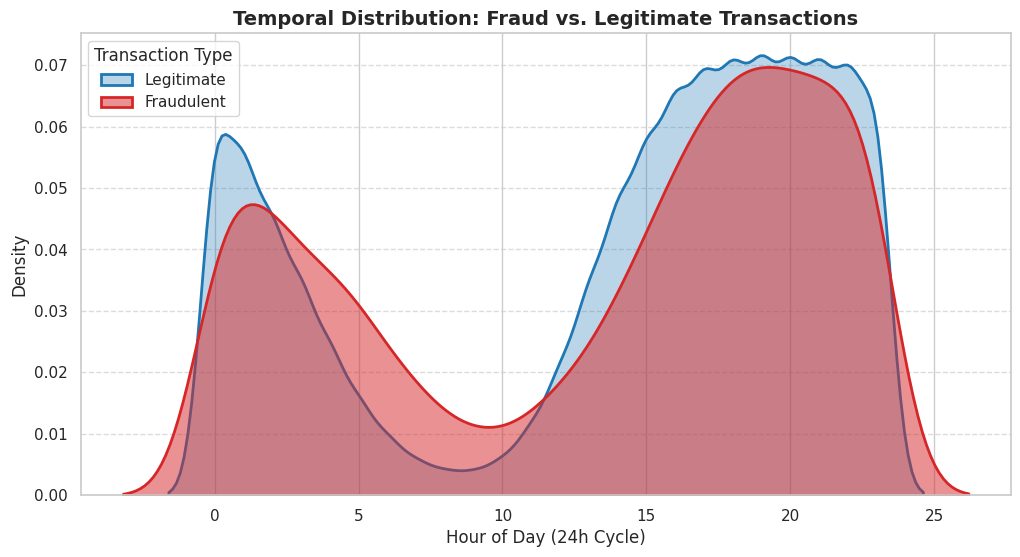

In [7]:
"""
Kde density plot normalizes both graphs
If we use normal bar graphs with 2 sticks, one fraud and one non-fraud then the non-fraud one will be too big
We won't be able to interpret the pattern of fraud transaction
It lets you compare the shape of the graphs rather than volume of it
"""
print("Plotting the transaction amount vs hour of the day kde density plot")

plt.figure(figsize=(12, 6))

# Using the modern 'fill' parameter and adding some styling
sns.kdeplot(
    data=df[df['isFraud'] == 0], x='hour', 
    label='Legitimate', fill=True, alpha=0.3, linewidth=2, color='#1f77b4'
)

sns.kdeplot(
    data=df[df['isFraud'] == 1], x='hour', 
    label='Fraudulent', fill=True, alpha=0.5, linewidth=2, color='#d62728'
)

plt.title('Temporal Distribution: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24h Cycle)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [8]:
# Trying to plot velocity of transaction by a user

# Approximate a unique cardholder
df['user_id'] = (
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str)
)

# Create hour-of-day feature (relative cycle)
df['hour'] = (df['TransactionDT'] // 3600) / 24  # keep total hours for velocity

# Group by user and hour
velocity = df.groupby(['user_id', 'hour', "isFraud"]).size().reset_index(name='transaction_count')

In [9]:
velocity

,user_id,hour,isFraud,transaction_count
0,10000_111.0_184.0,46.875000,0,1
1,10003_361.0_299.0,90.708333,0,1
2,10003_555.0_299.0,97.458333,0,1
3,10003_555.0_299.0,99.916667,0,2
4,10003_555.0_299.0,100.000000,0,1
...,...,...,...,...
488999,9999_174.0_330.0,162.750000,0,1
489000,9999_174.0_330.0,165.708333,0,1
489001,9999_174.0_330.0,166.625000,0,1
489002,9999_174.0_330.0,167.583333,0,1


In [10]:
velocity[velocity["isFraud"] == 1]

,user_id,hour,isFraud,transaction_count
24,10004_529.0_299.0,35.041667,1,1
117,10011_319.0_476.0,50.875000,1,1
118,10011_319.0_476.0,51.875000,1,1
120,10011_319.0_476.0,53.583333,1,1
121,10011_319.0_476.0,53.625000,1,1
...,...,...,...,...
488378,9992_455.0_310.0,98.916667,1,1
488813,9998_194.0_123.0,111.833333,1,1
488814,9998_194.0_123.0,112.625000,1,1
488985,9998_194.0_512.0,100.166667,1,1


Plotting KDE Density plot of velocity of transaction of users and fraud data


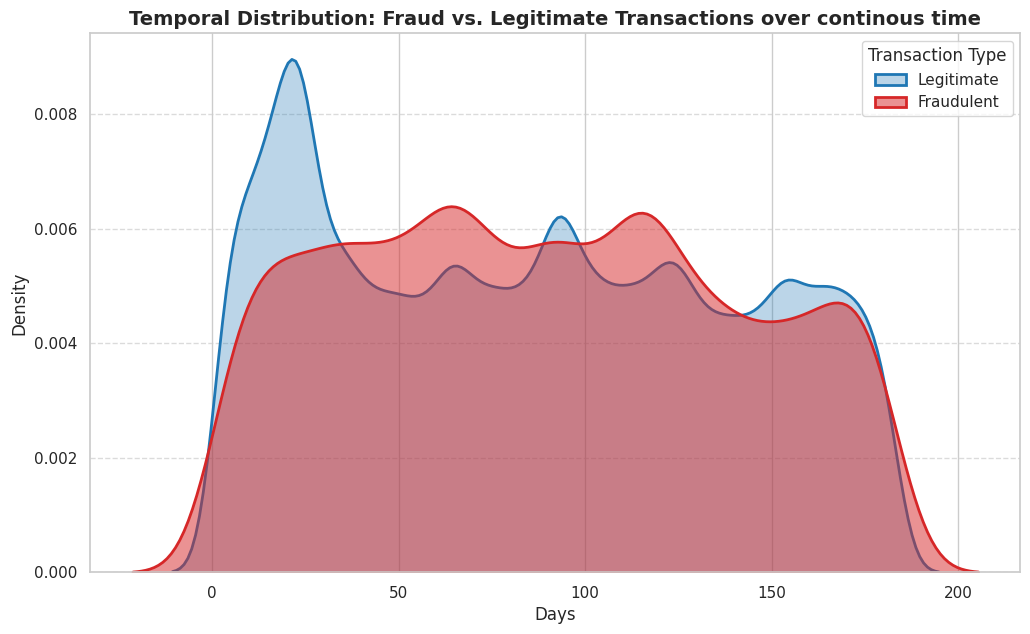

In [11]:
# We should again see a trend
print("Plotting KDE Density plot of velocity of transaction of users and fraud data")

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=velocity[velocity['isFraud'] == 0], x='hour', weights="transaction_count",
    label='Legitimate', fill=True, alpha=0.3, linewidth=2, color='#1f77b4'
)

sns.kdeplot(
    data=velocity[velocity['isFraud'] == 1], x='hour', weights="transaction_count",
    label='Fraudulent', fill=True, alpha=0.5, linewidth=2, color='#d62728'
)

plt.title('Temporal Distribution: Fraud vs. Legitimate Transactions over continous time', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Transaction Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

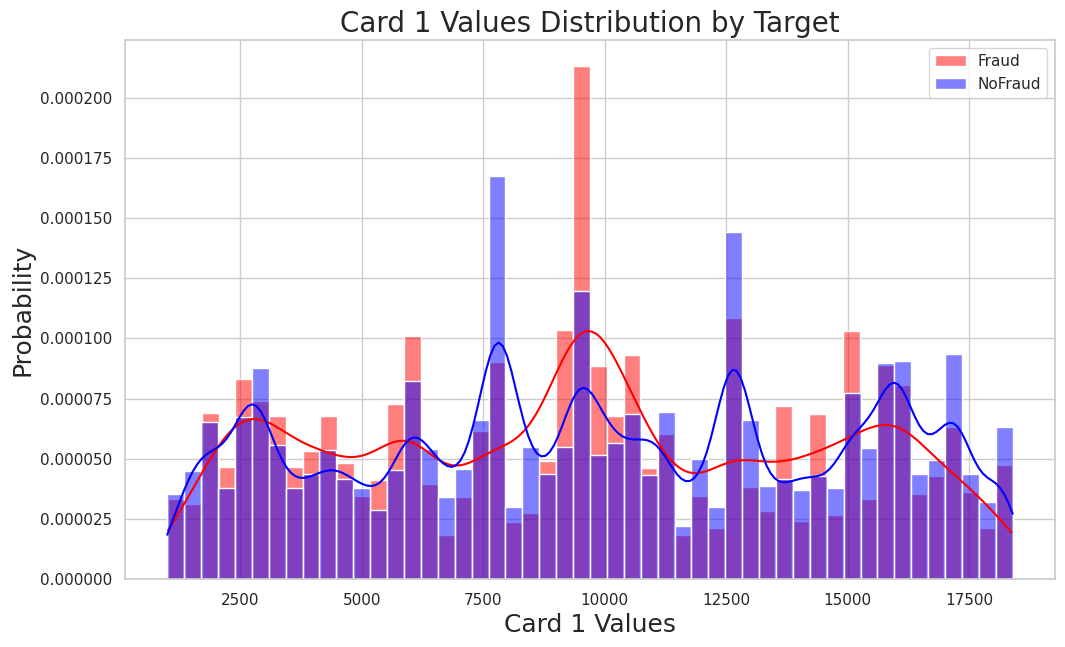

In [12]:
"""
Analysing the card1 values in our df
Result: Not much info gained, except particular card type has shown a bit of peak
"""

plt.figure(figsize=(12,7))

sns.histplot(df[df['isFraud'] == 1]['card1'], label='Fraud', kde=True, stat="density", bins=50, color='red')
sns.histplot(df[df['isFraud'] == 0]['card1'], label='NoFraud', kde=True, stat="density", bins=50, color='blue')

plt.legend()
plt.title("Card 1 Values Distribution by Target", fontsize=20)
plt.xlabel("Card 1 Values", fontsize=18)
plt.ylabel("Probability", fontsize=18)

plt.show()

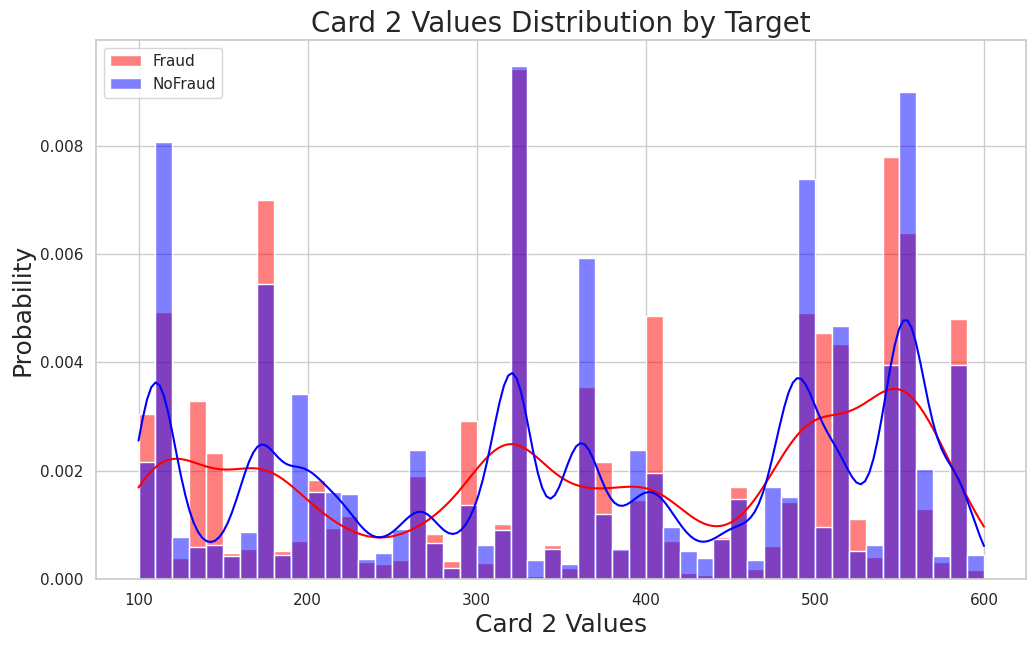

In [13]:
"""
Analysing the card2 values in our df
Result: Not much info gained, except last quater has more frauds?
"""

plt.figure(figsize=(12,7))

sns.histplot(df[df['isFraud'] == 1]['card2'], label='Fraud', kde=True, stat="density", bins=50, color='red')
sns.histplot(df[df['isFraud'] == 0]['card2'], label='NoFraud', kde=True, stat="density", bins=50, color='blue')

plt.legend()
plt.title("Card 2 Values Distribution by Target", fontsize=20)
plt.xlabel("Card 2 Values", fontsize=18)
plt.ylabel("Probability", fontsize=18)

plt.show()

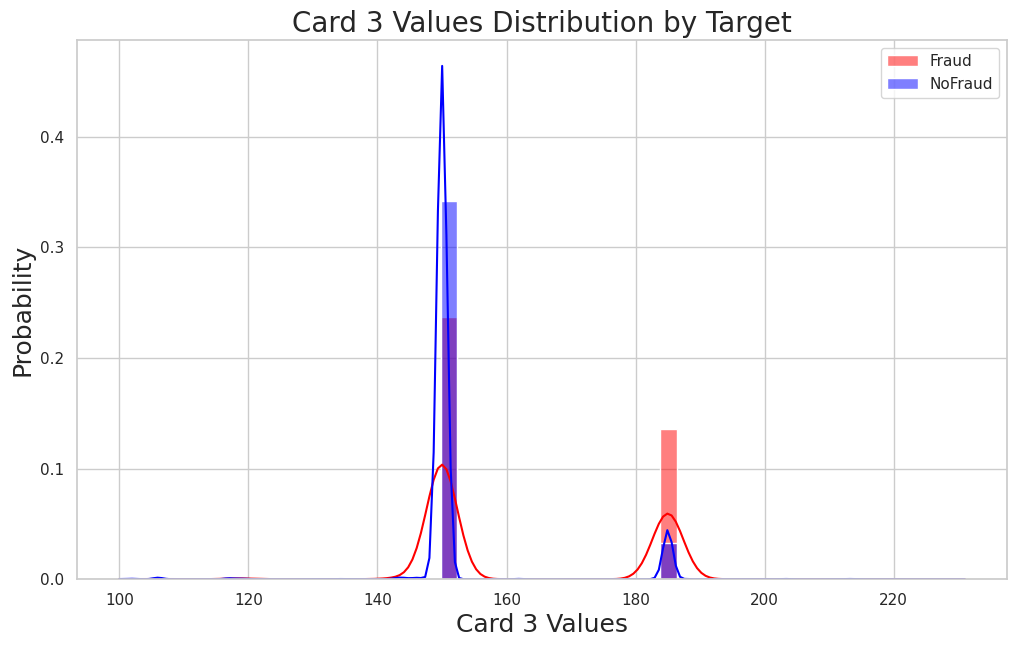

In [14]:
"""
Analysing the card3 values in our df
Result: Intrestingly one card value has the highest number but still has not much frauds.
"""

plt.figure(figsize=(12,7))

sns.histplot(df[df['isFraud'] == 1]['card3'], label='Fraud', kde=True, stat="density", bins=50, color='red')
sns.histplot(df[df['isFraud'] == 0]['card3'], label='NoFraud', kde=True, stat="density", bins=50, color='blue')

plt.legend()
plt.title("Card 3 Values Distribution by Target", fontsize=20)
plt.xlabel("Card 3 Values", fontsize=18)
plt.ylabel("Probability", fontsize=18)

plt.show()

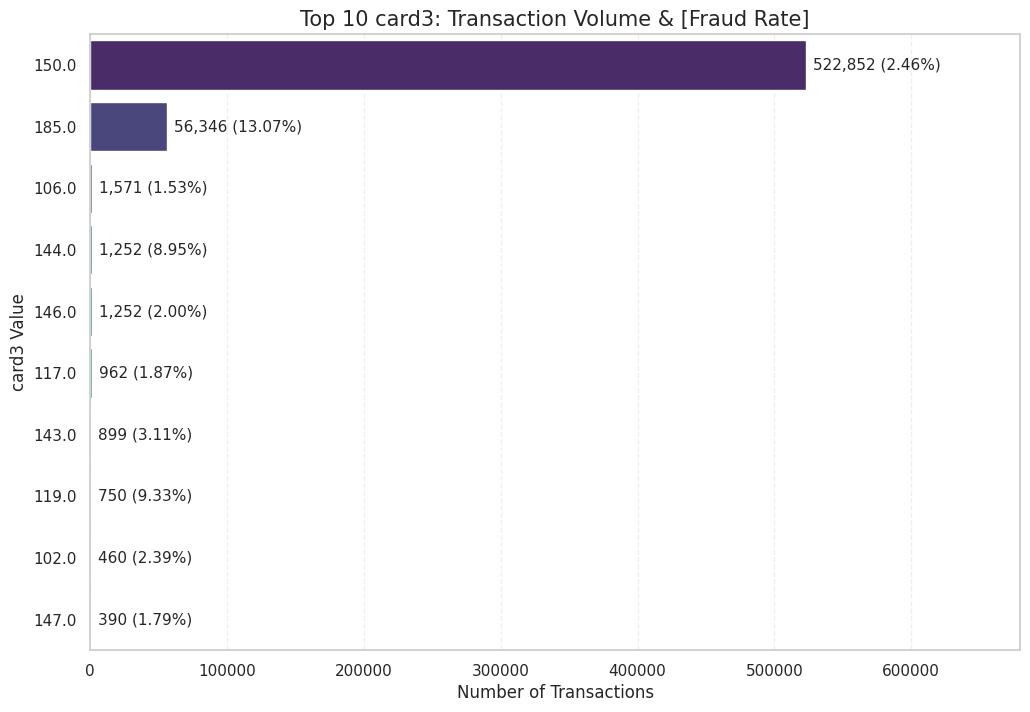

In [15]:
"""
Result: Card3 value 185 counts very low but has contri of 13% in fraudlent cases
"""

# 1. Prepare the data
res = df.groupby('card3')['isFraud'].agg(['count', 'mean']).reset_index()
res['mean'] = res['mean'] * 100 
res = res.sort_values('count', ascending=False).head(10)
res['card3_str'] = res['card3'].astype(str) # Create string column for plotting

plt.figure(figsize=(12, 8))

# 2. Updated Plotting Call (Fixed Warning)
ax = sns.barplot(
    x='count', 
    y='card3_str', 
    data=res, 
    hue='card3_str',  # Assign y to hue
    palette='viridis', 
    legend=False      # Hide the redundant legend
)

# 3. Annotate with Count and Fraud %
for i, p in enumerate(ax.patches):
    fraud_pct = res.iloc[i]['mean']
    count_val = int(res.iloc[i]['count'])
    
    annotation = f'{count_val:,} ({fraud_pct:.2f}%)'
    
    ax.annotate(annotation, 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                fontsize=11, xytext=(5, 0), 
                textcoords='offset points')

plt.title('Top 10 card3: Transaction Volume & [Fraud Rate]', fontsize=15)
plt.xlabel('Number of Transactions')
plt.ylabel('card3 Value')
plt.xlim(0, res['count'].max() * 1.3) # Space for text
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

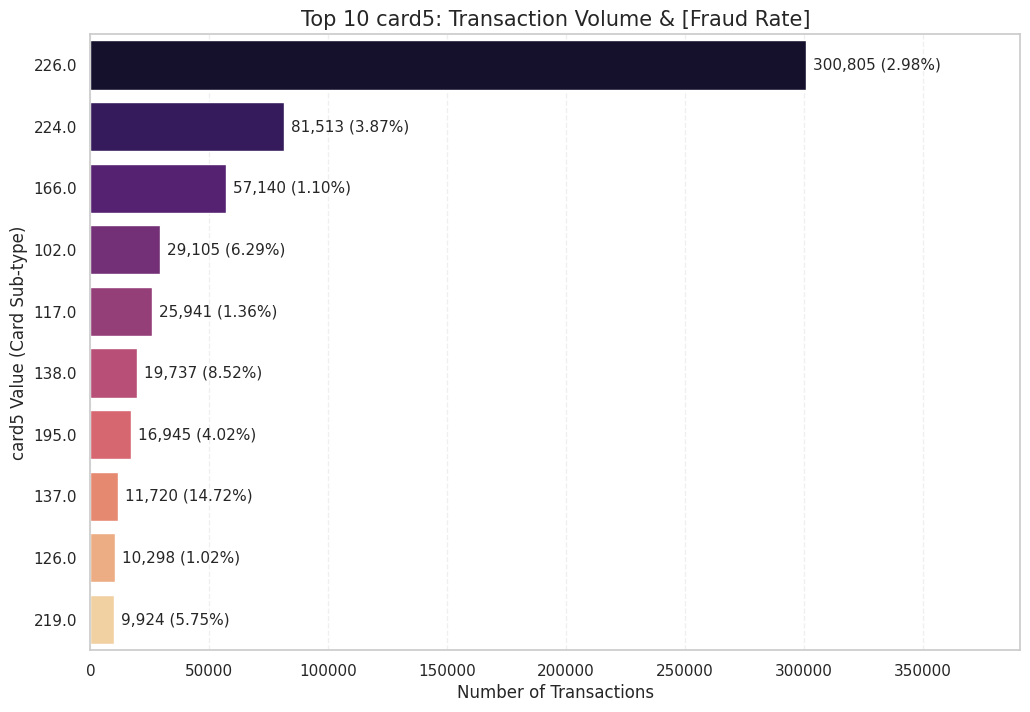

In [16]:
"""
Result: Same skewed distribution as Card3
Look at Card5 = 137, it counts for more than 14% in Fraudlent cases!
"""

# 1. Prepare the summary data for card5
res_card5 = df.groupby('card5')['isFraud'].agg(['count', 'mean']).reset_index()
res_card5['mean'] = res_card5['mean'] * 100  # Convert to percentage
res_card5 = res_card5.sort_values('count', ascending=False).head(10)
res_card5['card5_str'] = res_card5['card5'].astype(str)

plt.figure(figsize=(12, 8))

# 2. Plotting with 'hue' to avoid the FutureWarning
ax = sns.barplot(
    x='count', 
    y='card5_str', 
    data=res_card5, 
    hue='card5_str', 
    palette='magma', 
    legend=False
)

# 3. Annotate with Count and Fraud %
for i, p in enumerate(ax.patches):
    fraud_pct = res_card5.iloc[i]['mean']
    count_val = int(res_card5.iloc[i]['count'])
    
    # Text string: "Count (Fraud %)"
    annotation = f'{count_val:,} ({fraud_pct:.2f}%)'
    
    ax.annotate(annotation, 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', 
                fontsize=11, xytext=(5, 0), 
                textcoords='offset points')

plt.title('Top 10 card5: Transaction Volume & [Fraud Rate]', fontsize=15)
plt.xlabel('Number of Transactions')
plt.ylabel('card5 Value (Card Sub-type)')
plt.xlim(0, res_card5['count'].max() * 1.3)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()


In [75]:
# Card 4 and 6 had categorical data, whose labels are destroyed now :P
# Reloading the original data (with limited columns) for visualising those data

desired_columns = ["isFraud", "TransactionAmt", "card4", "card6", "P_emaildomain", "R_emaildomain"]
df_limited = pd.read_csv("../data/raw/ieee-fraud-detection/train_transaction.csv", usecols=desired_columns)

In [76]:
df_limited.isna().sum()

isFraud                0
TransactionAmt         0
card4               1577
card6               1571
P_emaildomain      94456
R_emaildomain     453249
dtype: int64

In [80]:
df_limited.fillna("Unkown", inplace=True)

/tmp/ipykernel_18140/2510788805.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_limited, x='card4', palette='viridis')


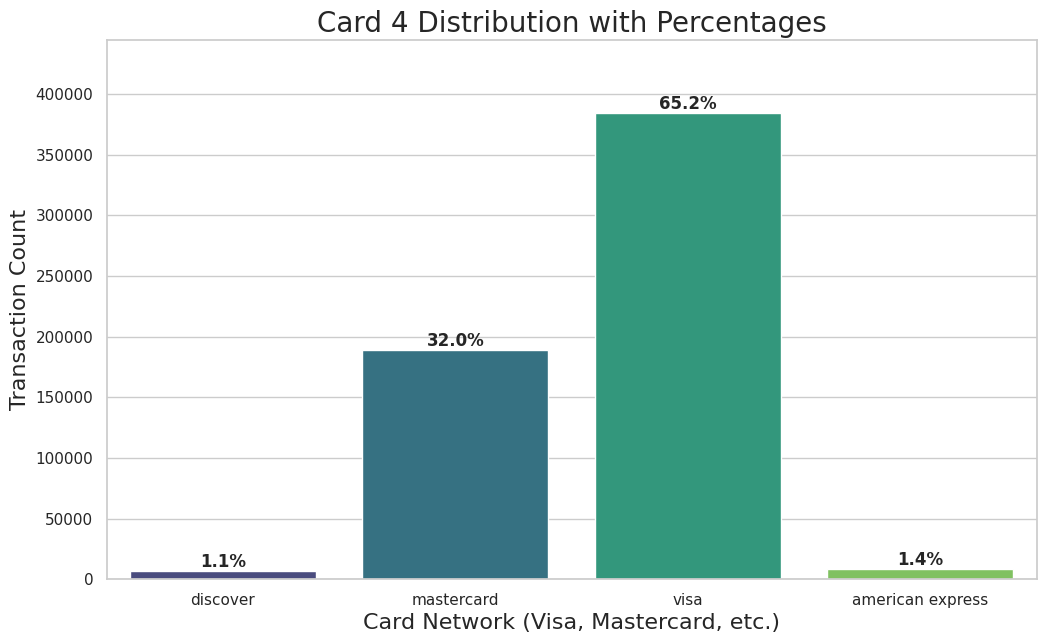

In [44]:
"""
Analysing the card 4 values in our df
Result: 64% cards are visa's and 32% mastercard, duopoly of these 2 giants
"""
plt.figure(figsize=(12, 7))

# 1. Create the countplot
ax = sns.countplot(data=df_limited, x='card4', palette='viridis')

# 2. Calculate percentages and annotate
total = len(df_limited['card4'])
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    # Get coordinates for the text
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    # Annotate the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Card 4 Distribution with Percentages", fontsize=20)
plt.xlabel("Card Network (Visa, Mastercard, etc.)", fontsize=16)
plt.ylabel("Transaction Count", fontsize=16)

# Adding a bit of "headroom" on the y-axis so text doesn't hit the top
plt.ylim(0, ax.get_ylim()[1] * 1.1) 

plt.show()

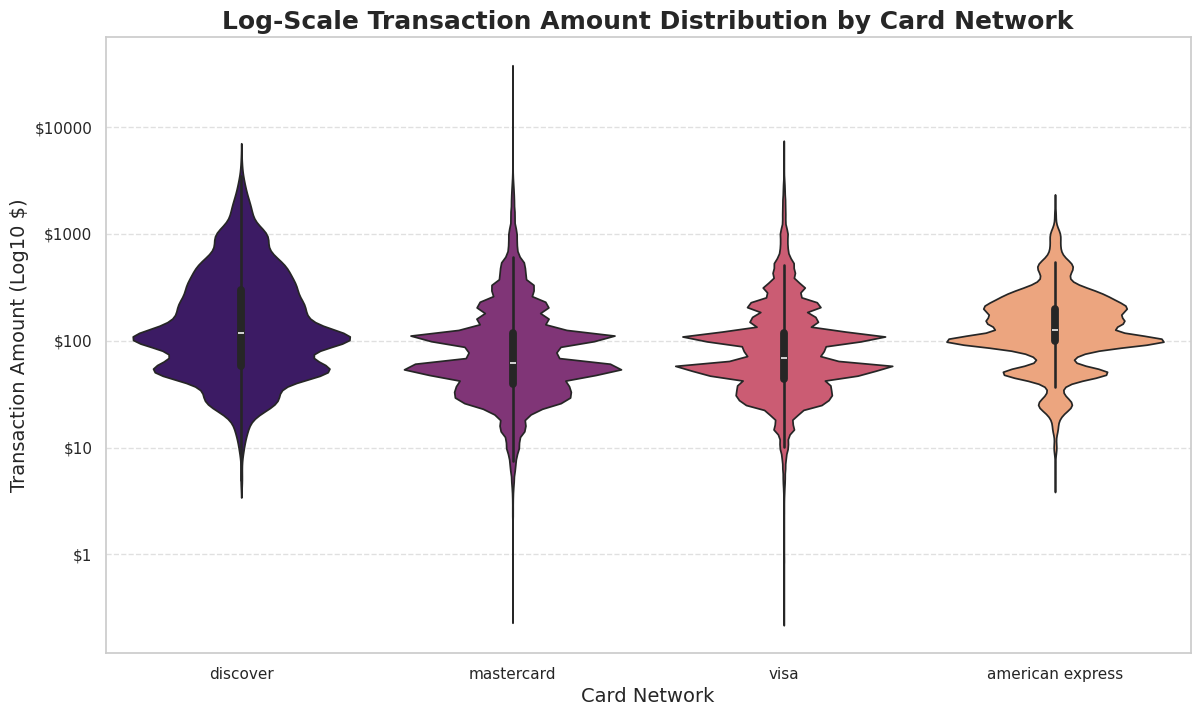

In [50]:
"""
Analysis: Analysing the distribution of these cards in transaction amount
Result: 
"""
plt.figure(figsize=(14, 8))

# 1. Create a Violin Plot to show the "density" and "spread" simultaneously
# Using log-transformed TransactionAmt to see the distribution clearly
ax = sns.violinplot(
    data=df_limited, 
    x='card4', 
    y=np.log10(df_limited['TransactionAmt']), 
    hue='card4',
    palette='magma', 
    legend=False
)

# 2. Styling for a Research Paper
plt.title("Log-Scale Transaction Amount Distribution by Card Network", fontsize=18, fontweight='bold')
plt.xlabel("Card Network", fontsize=14)
plt.ylabel("Transaction Amount (Log10 $)", fontsize=14)

# 3. Professional Touch: Update Y-ticks to show actual dollar values
# This makes log-scale plots much easier for humans to read
ticks = [1, 10, 100, 1000, 10000]
ax.set_yticks(np.log10(ticks))
ax.set_yticklabels([f'${t}' for t in ticks])

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_18140/3459019771.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_18140/3459019771.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


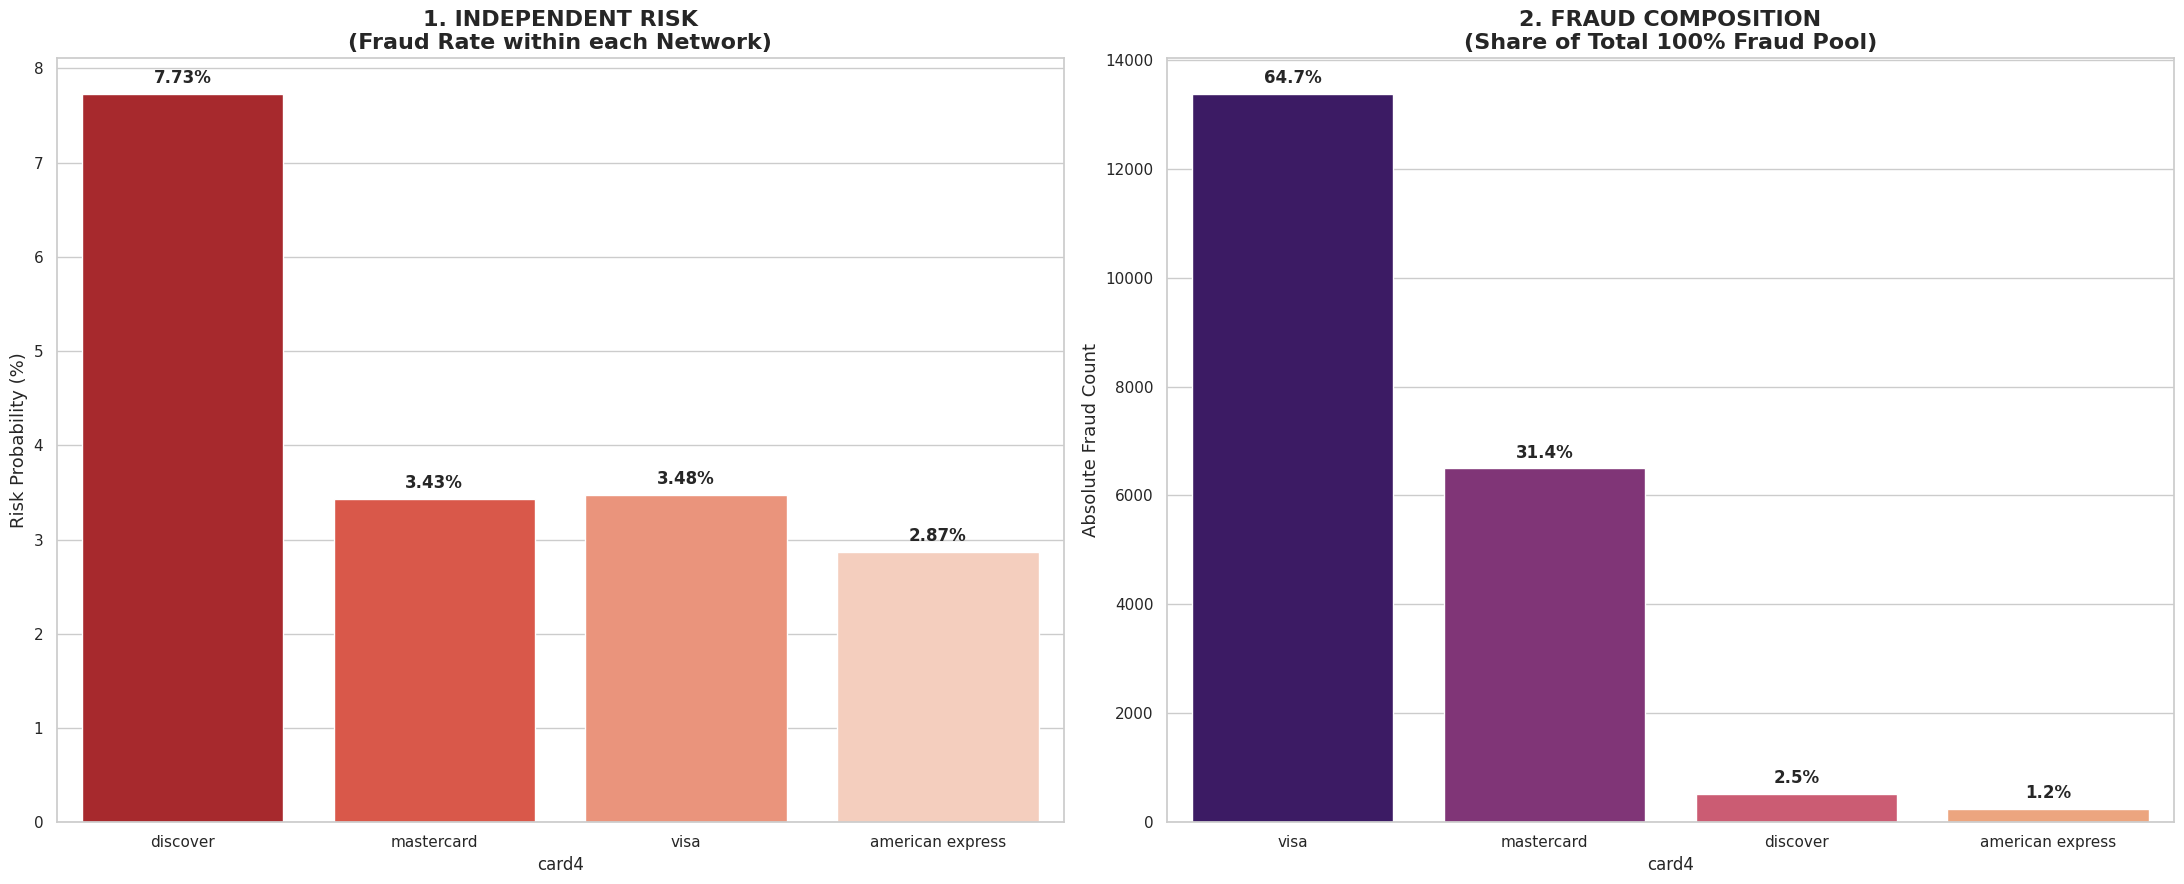

In [57]:
"""
Analysis: Calculating the fraud % in each card as well as overall contribution of cards in total frauds
Result: Discover cards do alot of frauds, 7 frauds from a 100 transactions done
And most of the frauds are done on visa's as mastercard's, which is obvious as they are the ones most used
"""

# Create the figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# --- LEFT PLOT: Independent Risk (P(Fraud | Card)) ---
# This shows the danger level of a single card transaction.
sns.barplot(
    data=df_limited, 
    x='card4', 
    y='isFraud', 
    palette='Reds_r', 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=None,
    ax=ax1
)
if ax1.get_legend(): ax1.get_legend().remove()

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax1.set_title("1. INDEPENDENT RISK\n(Fraud Rate within each Network)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Risk Probability (%)", fontsize=13)

# --- RIGHT PLOT: Fraud Composition (P(Card | Fraud)) ---
# This shows the 'share of the pie' out of all frauds (adds up to 100%).
df_fraud = df_limited[df_limited['isFraud'] == 1]
total_frauds = len(df_fraud)

sns.countplot(
    data=df_fraud, 
    x='card4', 
    palette='magma', 
    order=df_fraud['card4'].value_counts().index,
    ax=ax2
)
if ax2.get_legend(): ax2.get_legend().remove()

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_frauds:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax2.set_title("2. FRAUD COMPOSITION\n(Share of Total 100% Fraud Pool)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Absolute Fraud Count", fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_18140/222055756.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_limited, x='card6', palette='viridis')


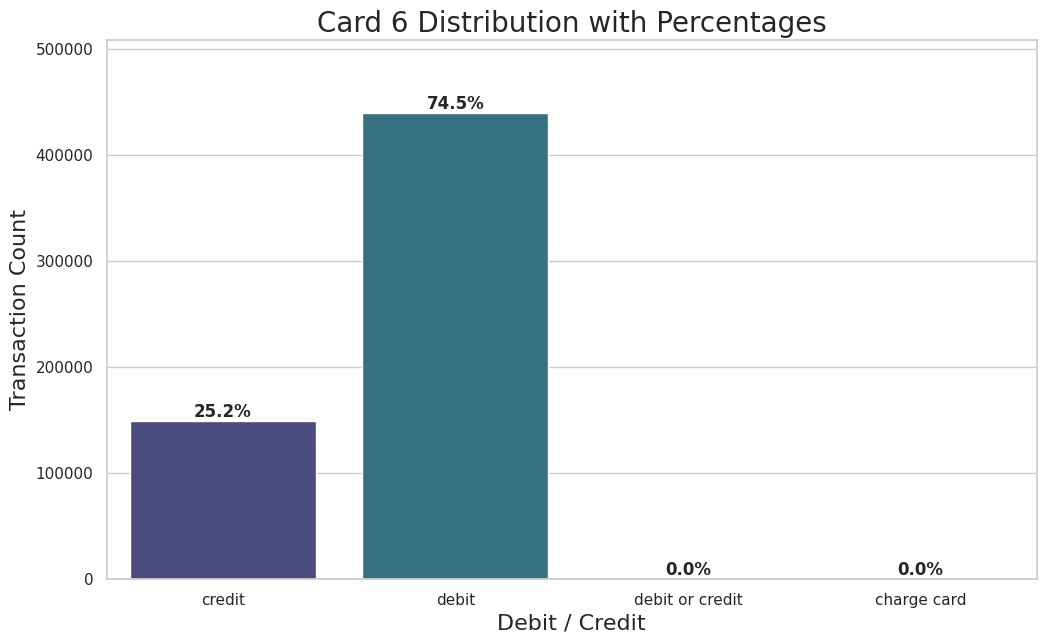

In [59]:
"""
Analysing the card 6 values in our df
Result: 64% cards are visa's and 32% mastercard, duopoly of these 2 giants
"""
plt.figure(figsize=(12, 7))

# 1. Create the countplot
ax = sns.countplot(data=df_limited, x='card6', palette='viridis')

# 2. Calculate percentages and annotate
total = len(df_limited['card6'])
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    # Get coordinates for the text
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    # Annotate the bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Card 6 Distribution with Percentages", fontsize=20)
plt.xlabel("Debit / Credit", fontsize=16)
plt.ylabel("Transaction Count", fontsize=16)

# Adding a bit of "headroom" on the y-axis so text doesn't hit the top
plt.ylim(0, ax.get_ylim()[1] * 1.1) 

plt.show()

/tmp/ipykernel_18140/1699328076.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_18140/1699328076.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


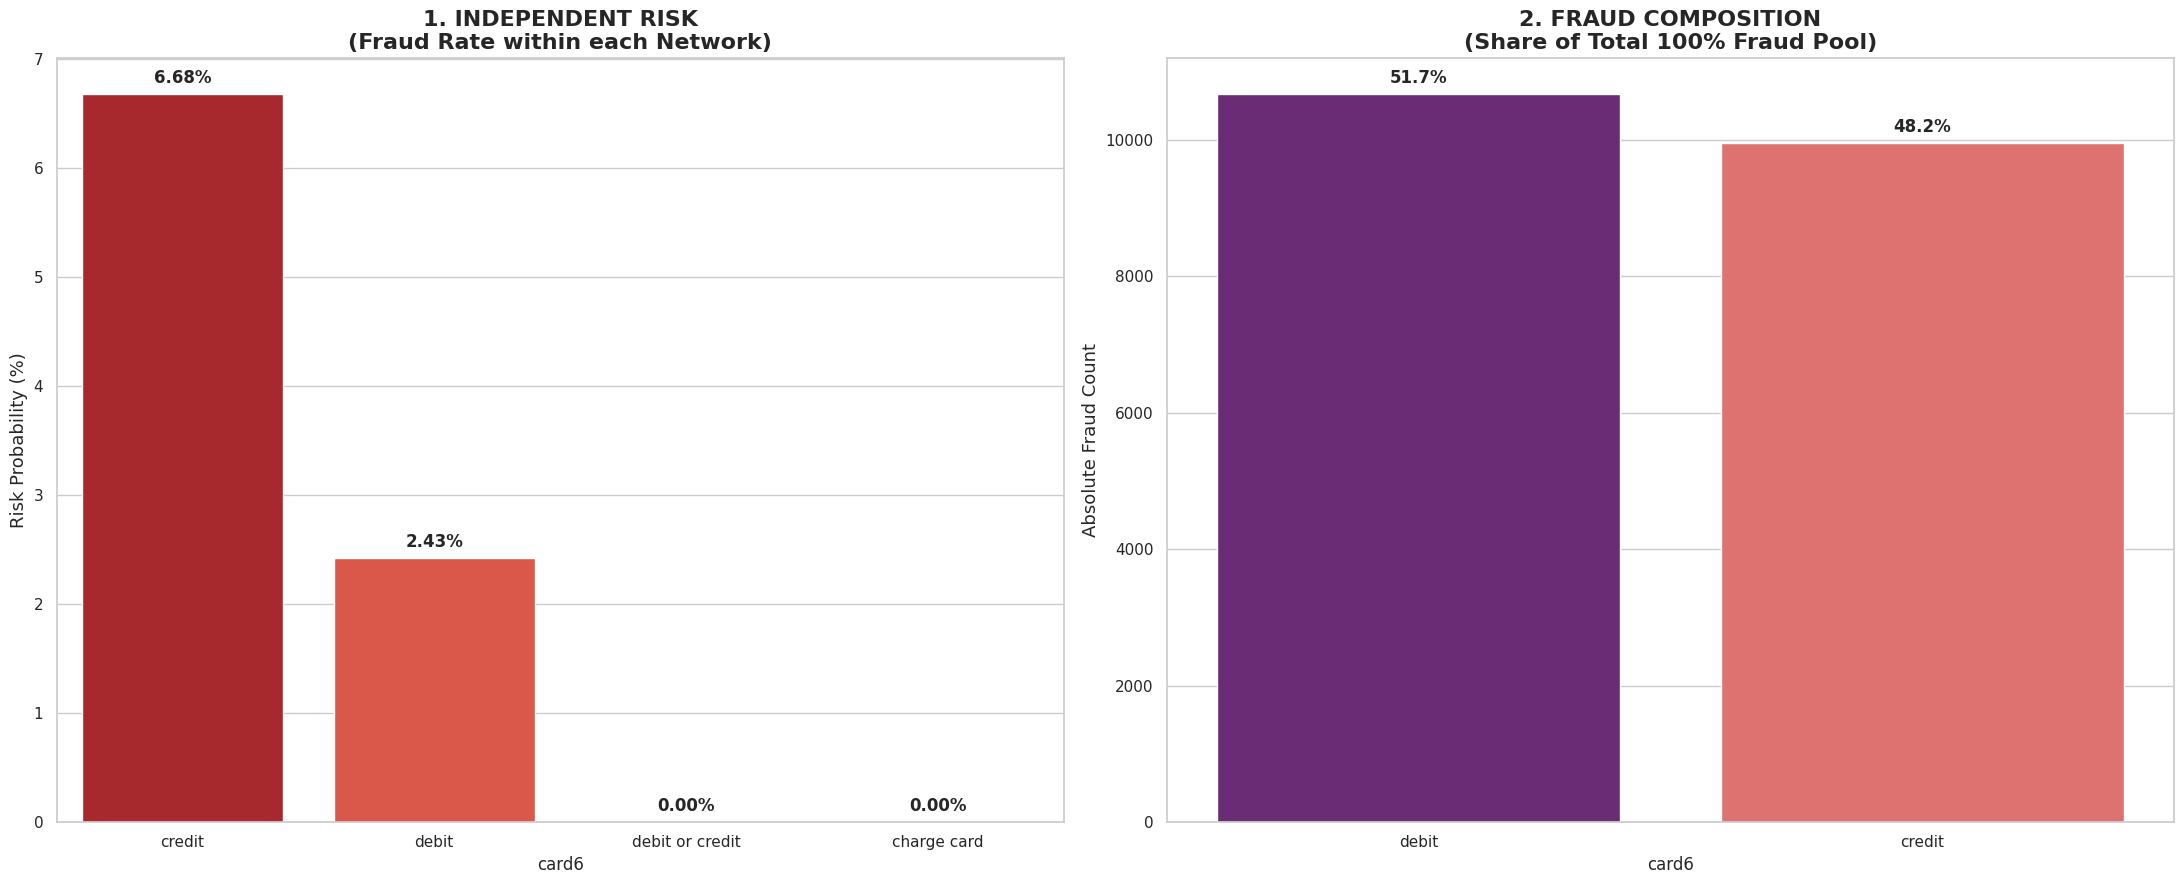

In [64]:
"""
Analysis: Calculating the fraud % in each type of transaction
Result: Overall its pretty equal, frauds are done in both debit as well as credit, despite debit being done more across banks
"""

# Create the figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# --- LEFT PLOT: Independent Risk (P(Fraud | Card)) ---
# This shows the danger level of a single card transaction.
sns.barplot(
    data=df_limited, 
    x='card6', 
    y='isFraud', 
    palette='Reds_r', 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=None,
    ax=ax1
)
if ax1.get_legend(): ax1.get_legend().remove()

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax1.set_title("1. INDEPENDENT RISK\n(Fraud Rate within each Network)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Risk Probability (%)", fontsize=13)

# --- RIGHT PLOT: Fraud Composition (P(Card | Fraud)) ---
# This shows the 'share of the pie' out of all frauds (adds up to 100%).
df_fraud = df_limited[df_limited['isFraud'] == 1]
total_frauds = len(df_fraud)

sns.countplot(
    data=df_fraud, 
    x='card6', 
    palette='magma', 
    order=df_fraud['card6'].value_counts().index,
    ax=ax2
)
if ax2.get_legend(): ax2.get_legend().remove()

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_frauds:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax2.set_title("2. FRAUD COMPOSITION\n(Share of Total 100% Fraud Pool)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Absolute Fraud Count", fontsize=13)

plt.tight_layout()
plt.show()

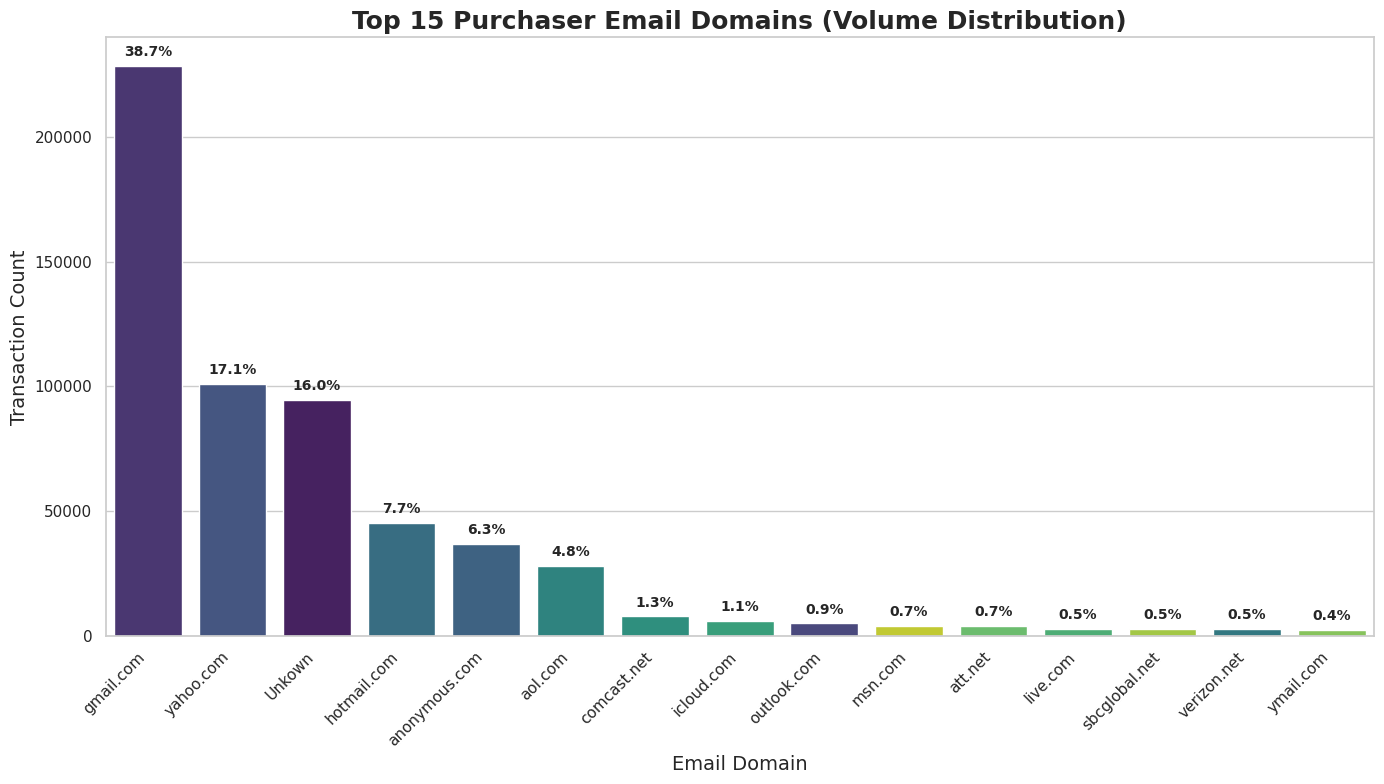

In [84]:
"""
Analysis: Count plot of p_emails
Result: Gmail and Yahoo are leading
"""
plt.figure(figsize=(14, 8))

# 1. Get the order of the Top 15 most frequent email domains
top_emails = df_limited['P_emaildomain'].value_counts().head(15).index

# 2. Create the plot for only those Top 15
ax = sns.countplot(
    data=df_limited[df_limited['P_emaildomain'].isin(top_emails)], 
    x='P_emaildomain', 
    hue='P_emaildomain',
    order=top_emails,
    palette='viridis',
    legend=False
)

# 3. Annotate with percentages
total_data = len(df_limited) # Use total dataset size for context
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_data:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.title("Top 15 Purchaser Email Domains (Volume Distribution)", fontsize=18, fontweight='bold')
plt.xlabel("Email Domain", fontsize=14)
plt.ylabel("Transaction Count", fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate for readability

plt.tight_layout()
plt.show()

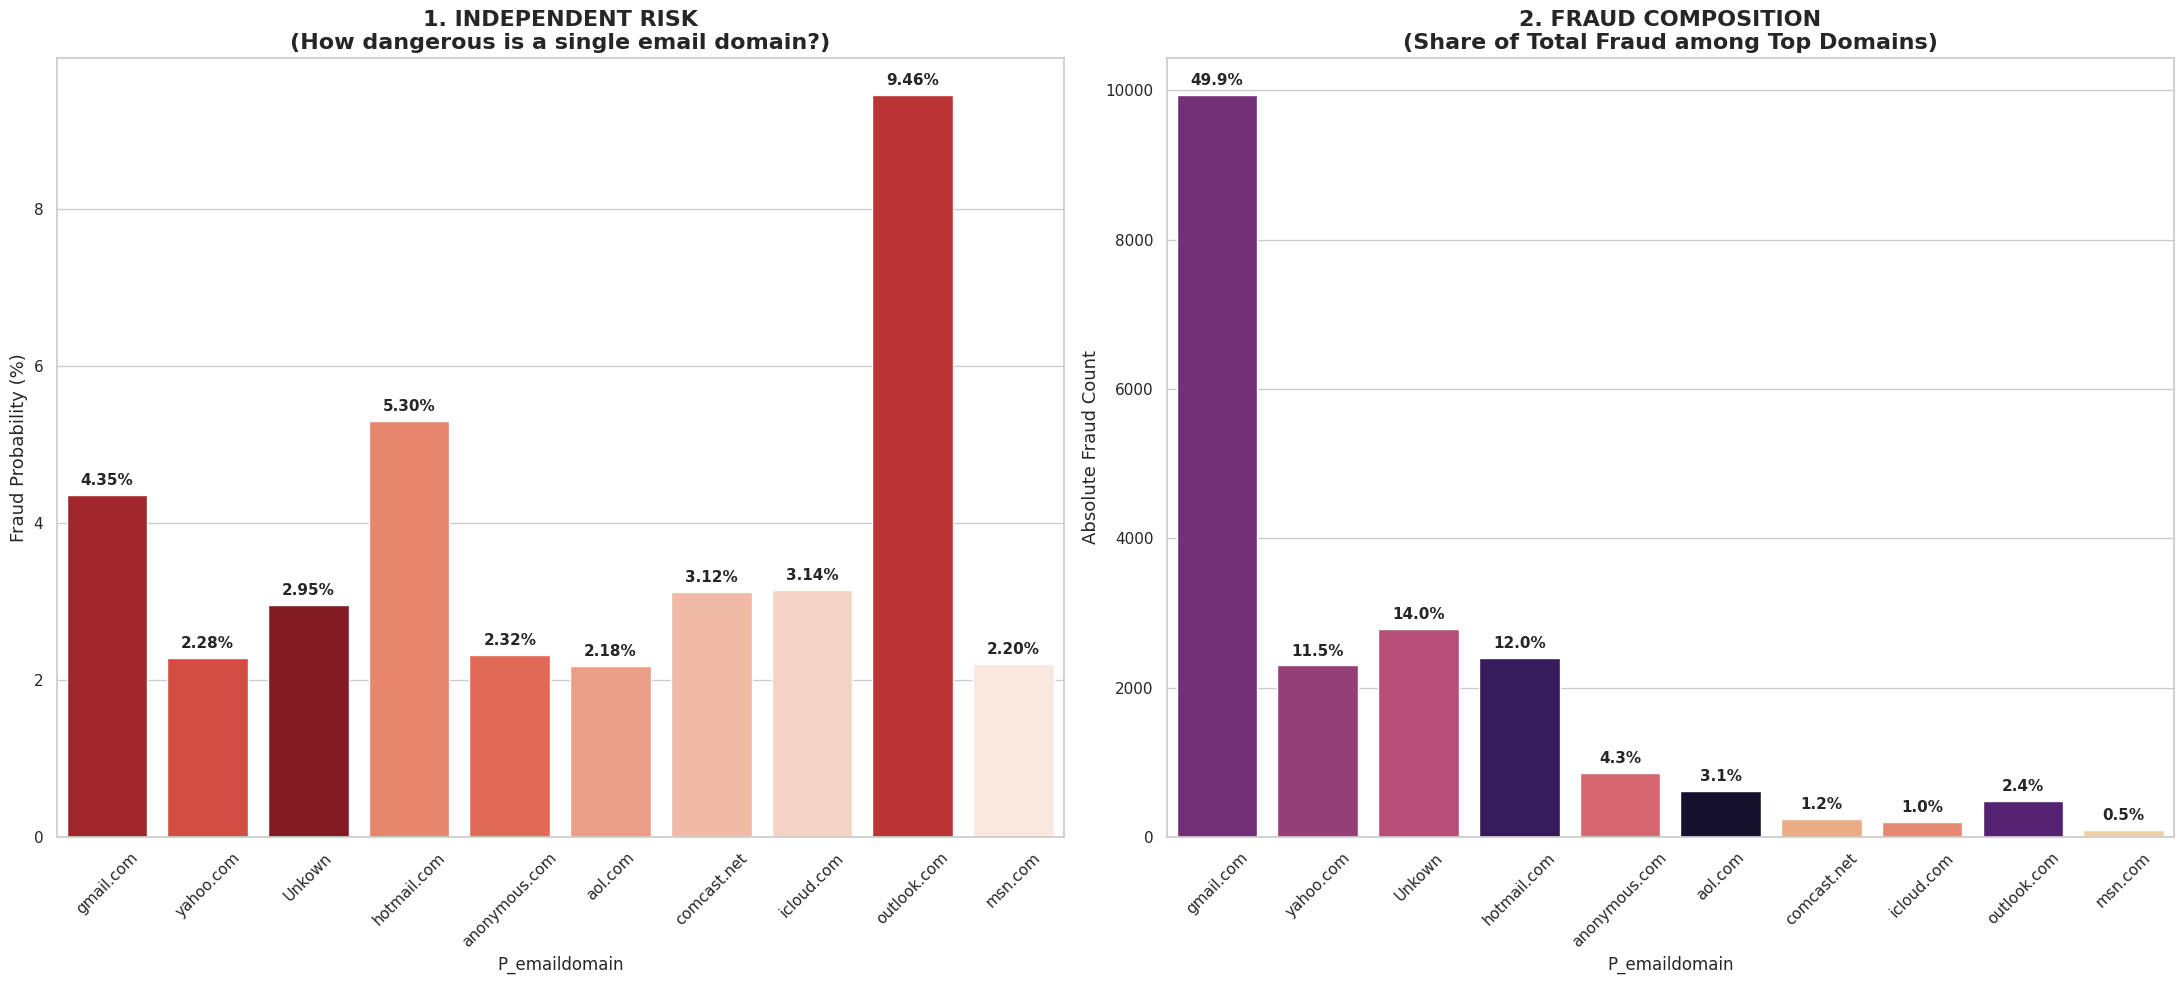

In [88]:
"""
Analysis: Seeing the percentage of frauds per 100 transaction through each senders email, and the total number of frauds from these emails
Result: Somehow Outlook see's alot of frauds in their senders userbase
"""

# 1. Identify Top 10 most frequent email domains
top_10_emails = df_limited['P_emaildomain'].value_counts().head(10).index
df_top = df_limited[df_limited['P_emaildomain'].isin(top_10_emails)]

# 2. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- LEFT PLOT: Independent Risk (P(Fraud | Email)) ---
sns.barplot(
    data=df_top, 
    x='P_emaildomain', 
    y='isFraud', 
    hue='P_emaildomain',
    palette='Reds_r', 
    order=top_10_emails,
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=None,
    ax=ax1,
    legend=False
)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax1.set_title("1. INDEPENDENT RISK\n(How dangerous is a single email domain?)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Fraud Probability (%)", fontsize=13)
ax1.tick_params(axis='x', rotation=45)

# --- RIGHT PLOT: Fraud Composition (P(Email | Fraud)) ---
df_fraud = df_top[df_top['isFraud'] == 1]
total_frauds_top = len(df_fraud)

sns.countplot(
    data=df_fraud, 
    x='P_emaildomain', 
    hue='P_emaildomain',
    palette='magma', 
    order=top_10_emails, # Keep same order as left plot for easy comparison
    ax=ax2,
    legend=False
)

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_frauds_top:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax2.set_title("2. FRAUD COMPOSITION\n(Share of Total Fraud among Top Domains)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Absolute Fraud Count", fontsize=13)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

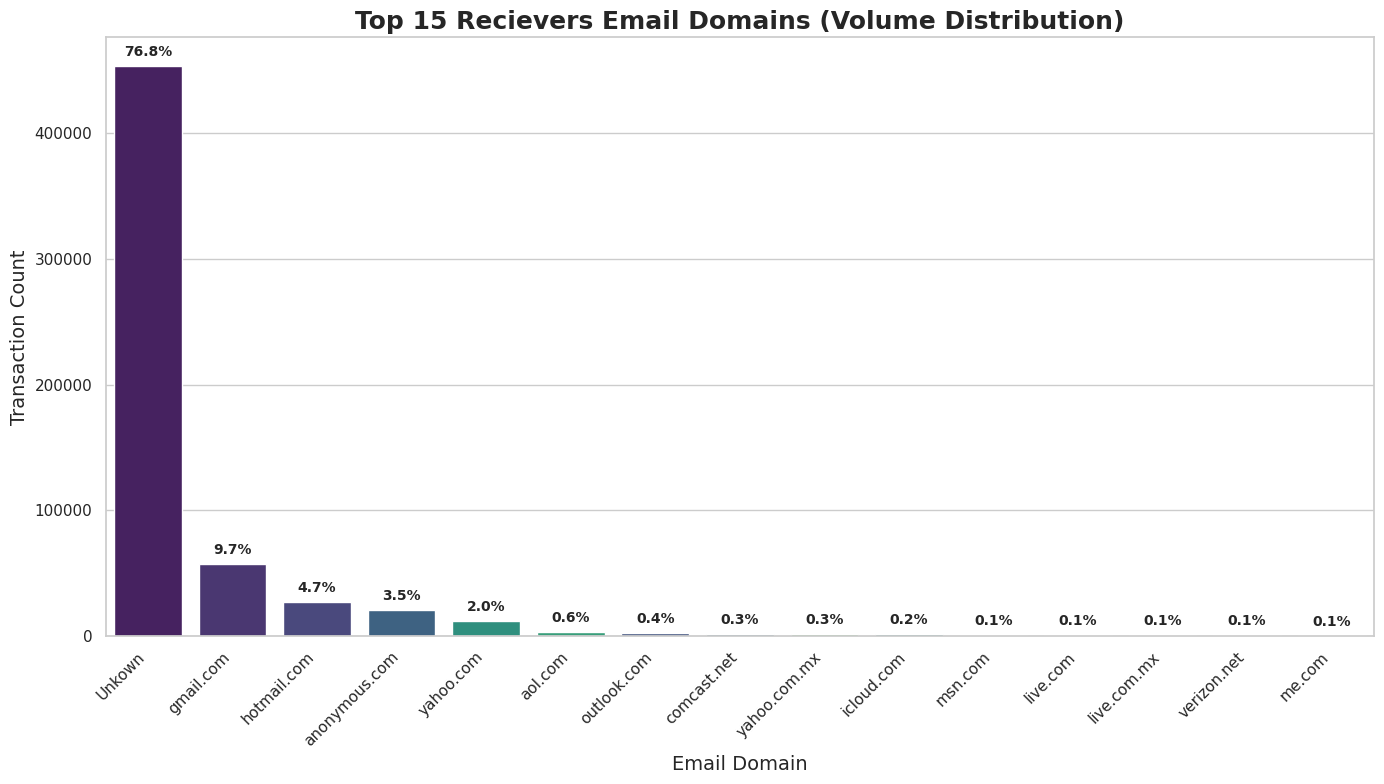

In [90]:
"""
Analysis: Count plot of r_email's
Result: A large portion of data on recievers is not available with the bank
"""
plt.figure(figsize=(14, 8))

# 1. Get the order of the Top 15 most frequent email domains
top_emails = df_limited['R_emaildomain'].value_counts().head(15).index

# 2. Create the plot for only those Top 15
ax = sns.countplot(
    data=df_limited[df_limited['R_emaildomain'].isin(top_emails)], 
    x='R_emaildomain', 
    hue='R_emaildomain',
    order=top_emails,
    palette='viridis',
    legend=False
)

# 3. Annotate with percentages
total_data = len(df_limited) # Use total dataset size for context
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_data:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.title("Top 15 Recievers Email Domains (Volume Distribution)", fontsize=18, fontweight='bold')
plt.xlabel("Email Domain", fontsize=14)
plt.ylabel("Transaction Count", fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate for readability

plt.tight_layout()
plt.show()

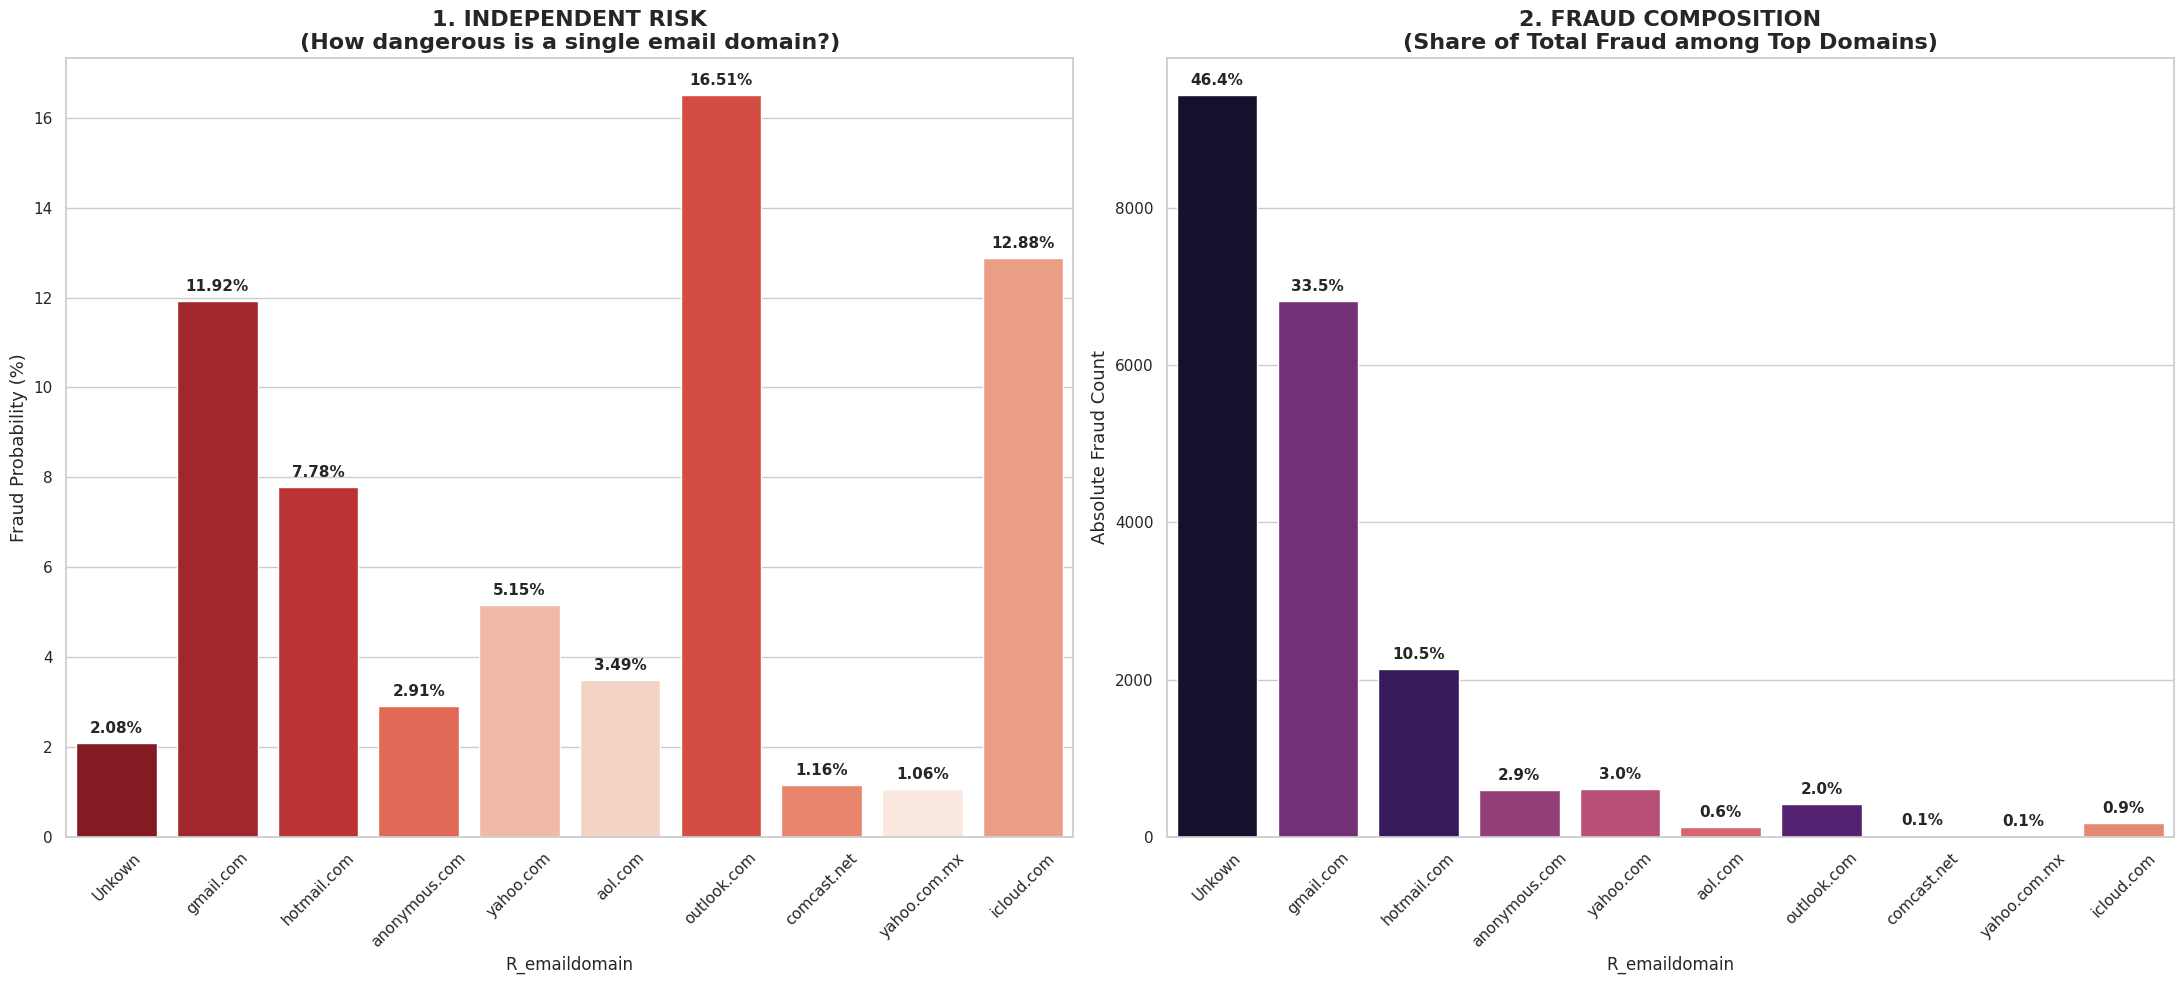

In [91]:
"""
Analysis: Seeing the percentage of frauds per 100 transaction through each recievers email, and the total number of frauds from these emails
Result: Cant really predict anything as there is little info we know :(
"""

# 1. Identify Top 10 most frequent email domains
top_10_emails = df_limited['R_emaildomain'].value_counts().head(10).index
df_top = df_limited[df_limited['R_emaildomain'].isin(top_10_emails)]

# 2. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- LEFT PLOT: Independent Risk (P(Fraud | Email)) ---
sns.barplot(
    data=df_top, 
    x='R_emaildomain', 
    y='isFraud', 
    hue='R_emaildomain',
    palette='Reds_r', 
    order=top_10_emails,
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=None,
    ax=ax1,
    legend=False
)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax1.set_title("1. INDEPENDENT RISK\n(How dangerous is a single email domain?)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Fraud Probability (%)", fontsize=13)
ax1.tick_params(axis='x', rotation=45)

# --- RIGHT PLOT: Fraud Composition (P(Email | Fraud)) ---
df_fraud = df_top[df_top['isFraud'] == 1]
total_frauds_top = len(df_fraud)

sns.countplot(
    data=df_fraud, 
    x='R_emaildomain', 
    hue='R_emaildomain',
    palette='magma', 
    order=top_10_emails, # Keep same order as left plot for easy comparison
    ax=ax2,
    legend=False
)

for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_frauds_top:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax2.set_title("2. FRAUD COMPOSITION\n(Share of Total Fraud among Top Domains)", fontsize=16, fontweight='bold')
ax2.set_ylabel("Absolute Fraud Count", fontsize=13)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [96]:
# Now analysing the addr1 distribution
len(set(df["addr1"])), len(df["addr1"])

(332, 590540)

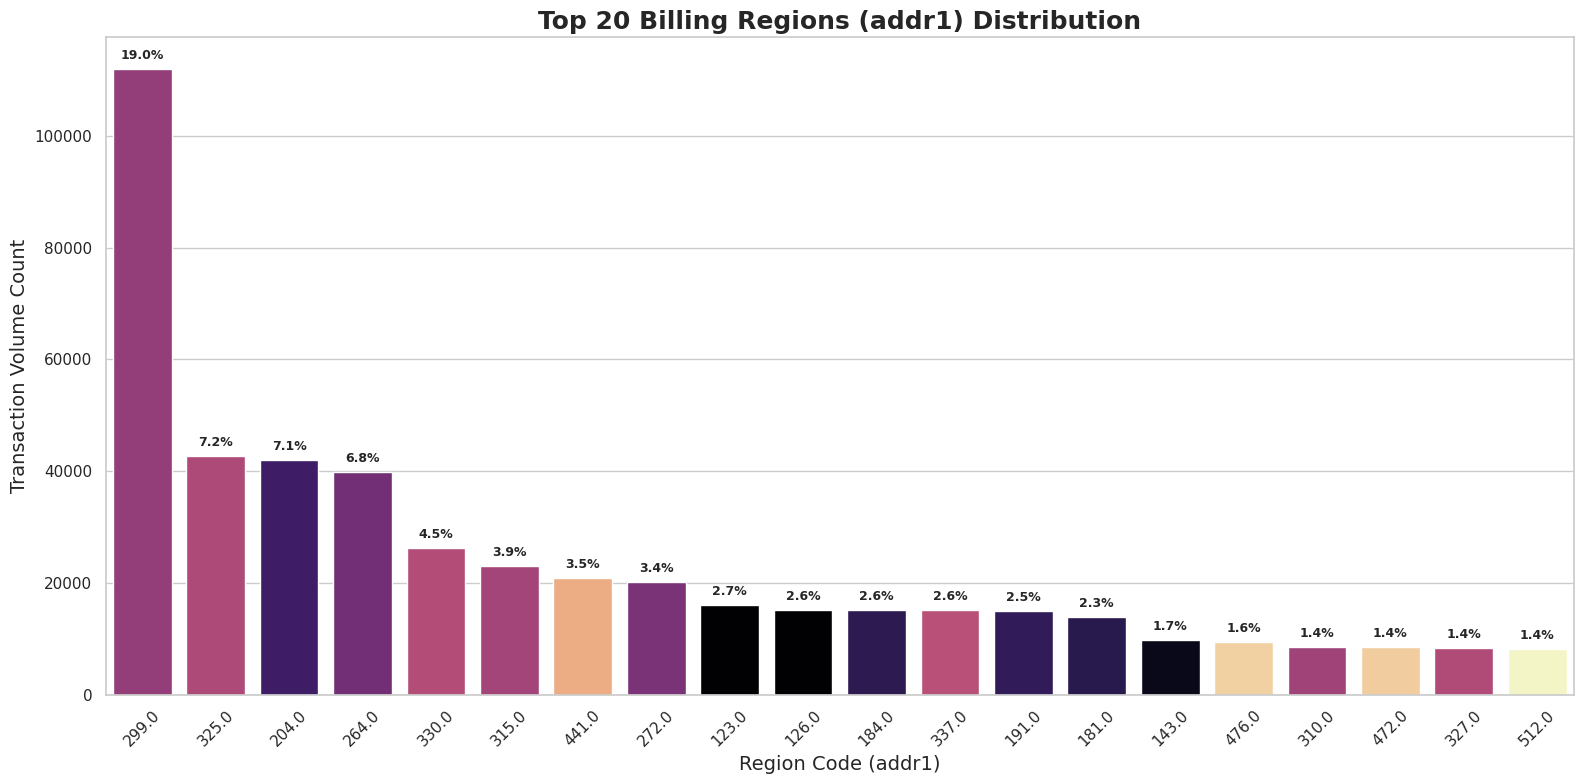

In [100]:
plt.figure(figsize=(16, 8))

# 1. Identify Top 20 most frequent regions
top_addr = df['addr1'].value_counts().head(20).index

# 2. Filter and Plot
ax = sns.countplot(
    data=df[df['addr1'].isin(top_addr)], 
    x='addr1', 
    hue='addr1',
    order=top_addr,
    palette='magma',
    legend=False
)

# 3. Annotate with percentages of the TOTAL dataset
total_len = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_len:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.title("Top 20 Billing Regions (addr1) Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Region Code (addr1)", fontsize=14)
plt.ylabel("Transaction Volume Count", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [109]:
df["addr1"].value_counts()

addr1
299.0    112041
325.0     42751
204.0     42020
264.0     39870
330.0     26287
          ...  
386.0         1
101.0         1
353.0         1
516.0         1
245.0         1
Name: count, Length: 332, dtype: int64

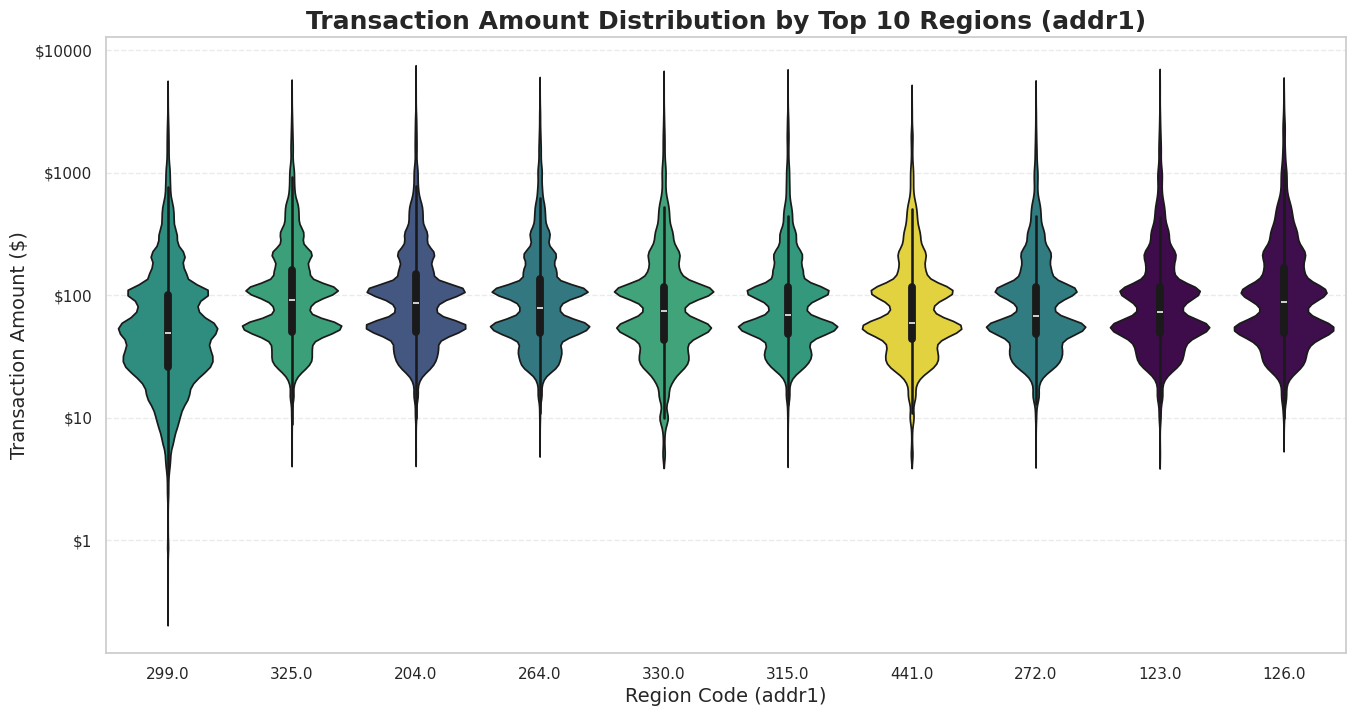

In [104]:
"""
Analysis: Violin plot of the above top 10 areas
Result: most transaction are of less amount
"""

top_addr = df['addr1'].value_counts().head(10).index
df_top_addr = df[df['addr1'].isin(top_addr)].copy()

df_top_addr['Log_Amt'] = np.log10(df_top_addr['TransactionAmt'])

plt.figure(figsize=(16, 8))

# It's better than a Box Plot for large datasets with many outliers
ax = sns.violinplot(
    data=df_top_addr, 
    x='addr1', 
    y='Log_Amt', 
    hue='addr1',
    palette='viridis',
    order=top_addr,
    legend=False
)

# 4. Professional Formatting
plt.title("Transaction Amount Distribution by Top 10 Regions (addr1)", fontsize=18, fontweight='bold')
plt.xlabel("Region Code (addr1)", fontsize=14)
plt.ylabel("Transaction Amount ($)", fontsize=14)

# 5. Fix Y-axis labels to show actual dollar amounts
ticks = [1, 10, 100, 1000, 10000]
ax.set_yticks(np.log10(ticks))
ax.set_yticklabels([f'${t}' for t in ticks])

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

/tmp/ipykernel_18140/1966391334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


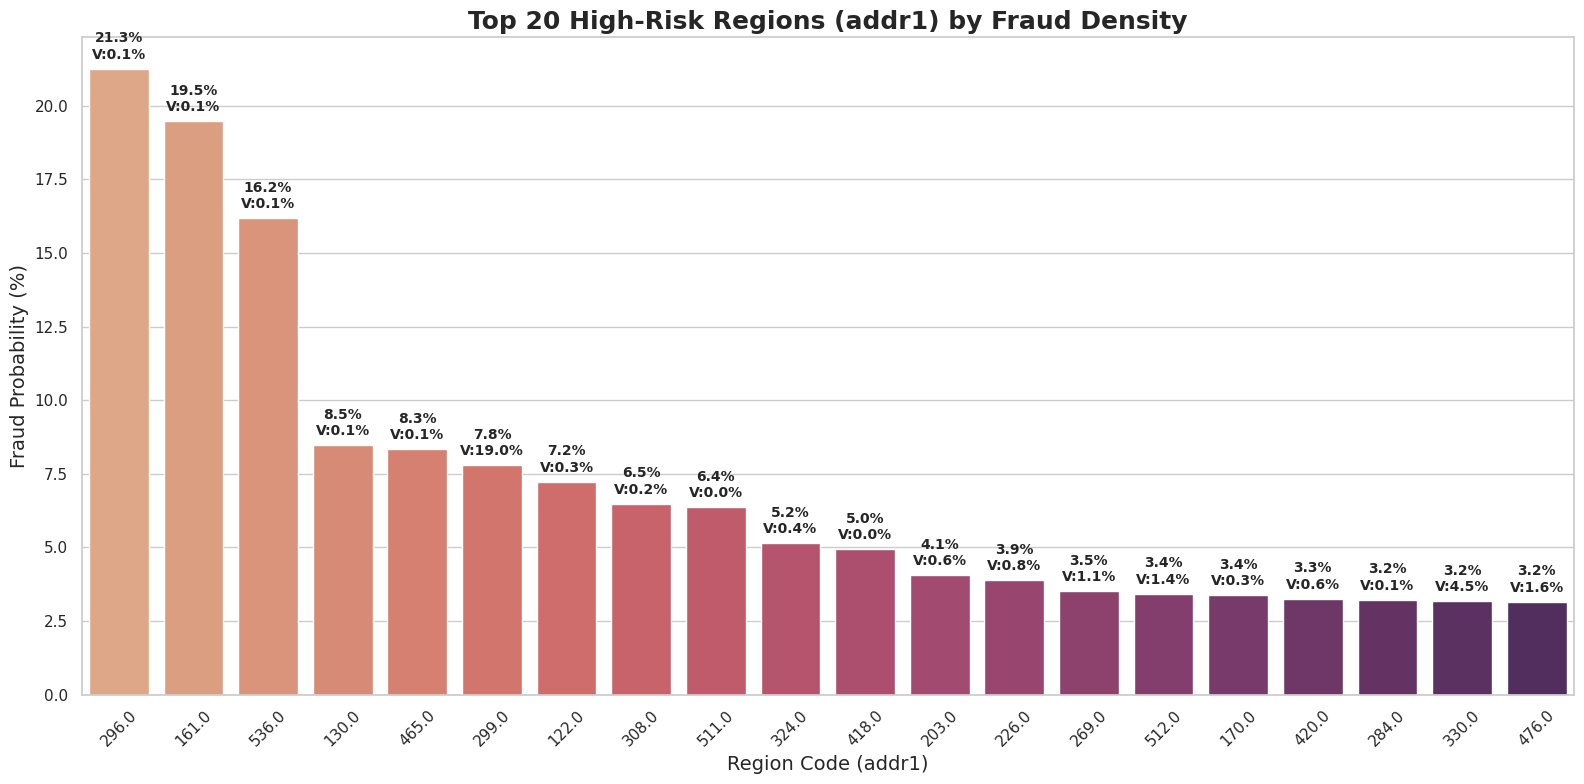

In [133]:
"""
Analysis: Finding out the highest probability 
Result: 
"""
# 1. Filter for regions with at least 100 transactions to ensure statistical significance
addr_counts = df['addr1'].value_counts()
df_sig = df[df['addr1'].isin(significant_addr)]

# 2. Calculate Fraud % per Region and take the Top 20
top_risk_addr = df_sig.groupby('addr1')['isFraud'].mean().sort_values(ascending=False).head(20) * 100

plt.figure(figsize=(16, 8))

# 3. Create the bar plot
ax = sns.barplot(
    x=top_risk_addr.index, 
    y=top_risk_addr.values, 
    palette='flare', 
    legend=False,
    order=top_risk_addr.index
)
count = 0
for p in ax.patches:
    height = p.get_height()
    
    # Only process bars that are actually visible (height > 0)
    if height > 0:
        # Now 'count' correctly maps to the visible bars (0 through 19)
        x_val = top_risk_addr.index[count]
       
        # Calculate Volume %
        vol_pct = (addr_counts[x_val] / len(df)) * 100
        
        ax.annotate(f'{height:.1f}%\nV:{vol_pct:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', 
                    xytext=(0, 5), textcoords='offset points')
        
        count += 1 # Only increment for real bars

plt.title("Top 20 High-Risk Regions (addr1) by Fraud Density", fontsize=18, fontweight='bold')
plt.xlabel("Region Code (addr1)", fontsize=14)
plt.ylabel("Fraud Probability (%)", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_18140/218954379.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


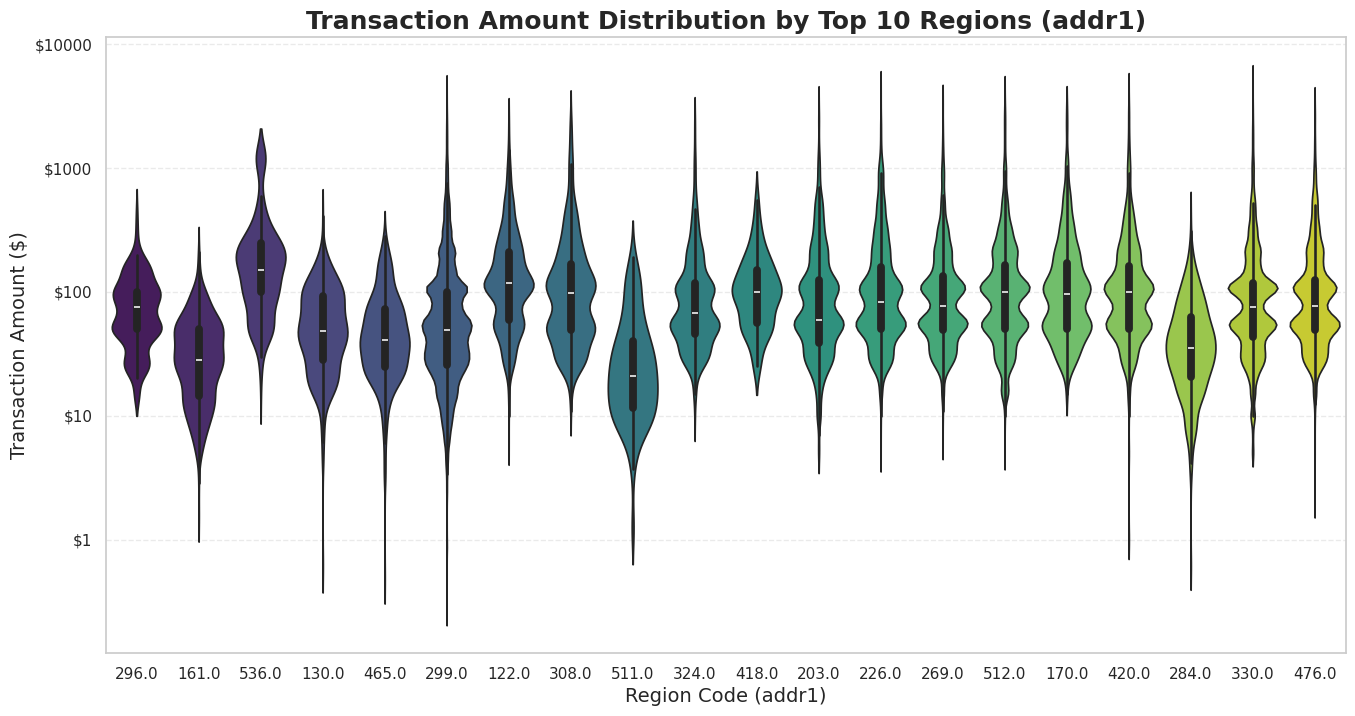

In [142]:
"""
Analysis: Violin plot of the most fraudlent areas
Result: Fraud is happening on good amounts
"""
# 2. Calculate Fraud % per Region and take the Top 20
top_risk_addr = df_sig.groupby('addr1')['isFraud'].mean().sort_values(ascending=False).head(20)
df_top_addr = df[df['addr1'].isin(top_risk_addr.index)].copy()

df_top_addr['Log_Amt'] = np.log10(df_top_addr['TransactionAmt'])

plt.figure(figsize=(16, 8))

# It's better than a Box Plot for large datasets with many outliers
ax = sns.violinplot(
    data=df_top_addr, 
    x='addr1', 
    y='Log_Amt', 
    palette='viridis',
    order=top_risk_addr.index,
    legend=False
)

# 4. Professional Formatting
plt.title("Transaction Amount Distribution by Top 10 Regions (addr1)", fontsize=18, fontweight='bold')
plt.xlabel("Region Code (addr1)", fontsize=14)
plt.ylabel("Transaction Amount ($)", fontsize=14)

# 5. Fix Y-axis labels to show actual dollar amounts
ticks = [1, 10, 100, 1000, 10000]
ax.set_yticks(np.log10(ticks))
ax.set_yticklabels([f'${t}' for t in ticks])

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [143]:
# Now analysing the addr1 distribution
len(set(df["addr2"])), len(df["addr2"])

(74, 590540)

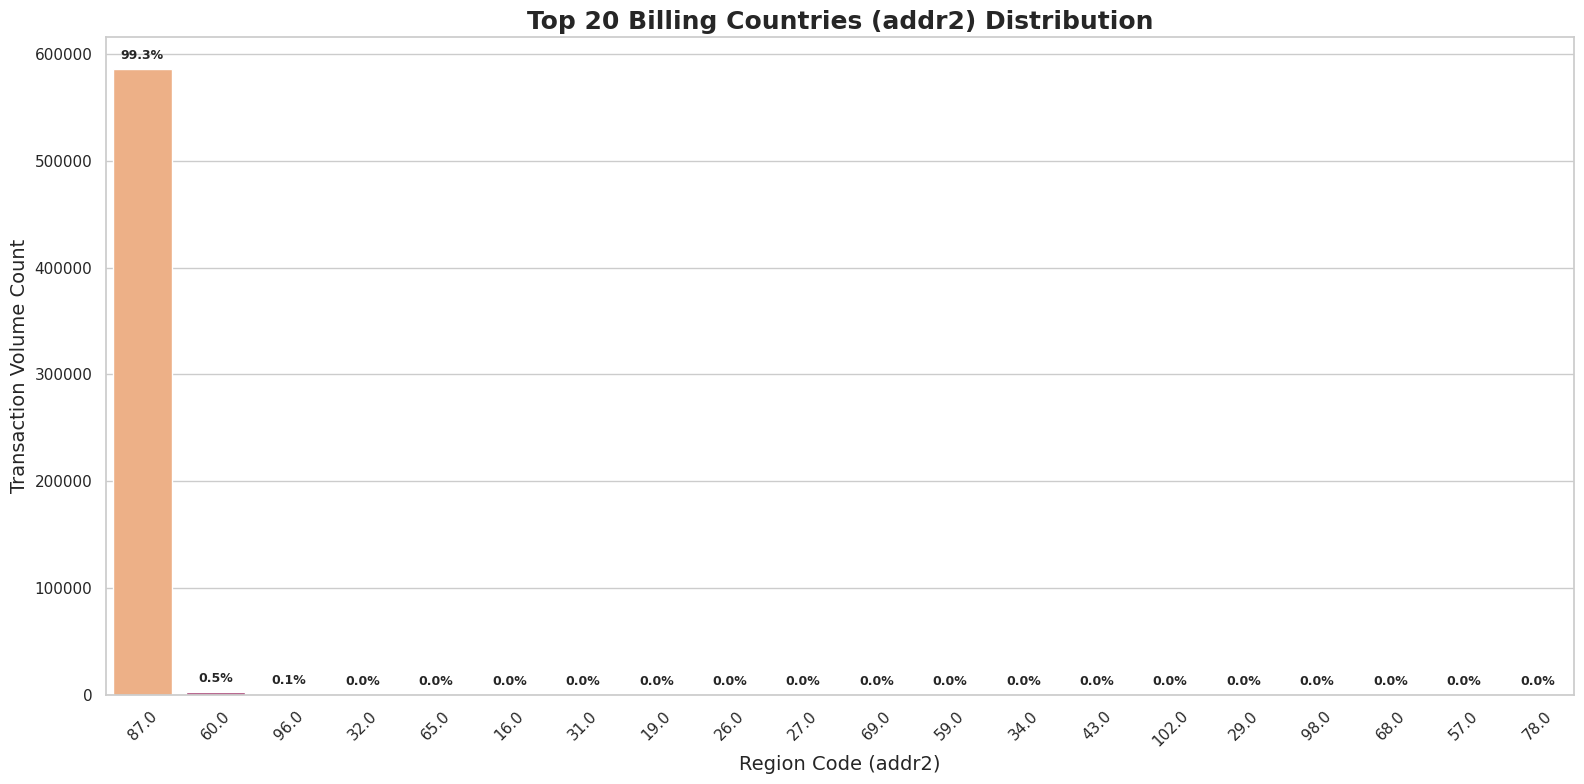

In [150]:
"""
Analysis: Volumetric graph of addr2
Result: Nearly all of the transactions are occuring from same addr2. So it probably indicates country code, nearly all transactions happen inside the country
""" 

plt.figure(figsize=(16, 8))

# 1. Identify Top 20 most frequent regions
top_addr = df['addr2'].value_counts().head(20).index

# 2. Filter and Plot
ax = sns.countplot(
    data=df[df['addr2'].isin(top_addr)], 
    x='addr2', 
    hue='addr2',
    order=top_addr,
    palette='magma',
    legend=False
)

# 3. Annotate with percentages of the TOTAL dataset
total_len = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_len:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.title("Top 20 Billing Countries (addr2) Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Region Code (addr2)", fontsize=14)
plt.ylabel("Transaction Volume Count", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [158]:
"""
As other countries have very less transactions so any fraud will give higher % probability
and as country 87 has highest volume of transaction, the fraud % will be extremely similar to total fraud % of the dataset
"""
print(f"Total fraud percentage of dataset: {df['isFraud'].mean()*100}")
print(f'Fraud % of country (addr2 = 87): {df[df["addr2"] == 87]["isFraud"].mean()*100}')

Total fraud percentage of dataset: 3.4990009144173126
Fraud % of country (addr2 = 87): 3.449070006670226
